# 01. Plan-and-Execute 패턴

> **왜 Plan-and-Execute 패턴이 필요한가요?**
>
> 일반 ReAct 에이전트는 "한 걸음씩" 행동해요. 하지만 복잡한 작업("시장 조사 보고서 작성")은 **먼저 전체 계획을 세우고** 각 단계를 실행하는 것이 더 효율적이에요. Plan-and-Execute는 에이전트에게 **"먼저 생각하고 나서 행동하라"** 고 가르치는 패턴이에요.

> 🔑 **비유**: ReAct 에이전트가 **즉흥 여행자**라면, Plan-and-Execute 에이전트는 **여행 계획표를 만들고 따르는 여행자**예요. 계획이 있으면 빠뜨리는 것 없이 체계적으로 진행할 수 있어요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. Plan-and-Execute 패턴의 핵심 개념과 ReAct 에이전트와의 차이를 설명할 수 있어요
2. `PlanExecute` 상태(State)와 Pydantic 모델을 정의하고 구조화된 출력을 활용할 수 있어요
3. Planner → Execute → Replan 루프를 LangGraph StateGraph로 구현할 수 있어요
4. 계획 단계와 실행 단계에 서로 다른 모델을 사용하는 비용 최적화 전략을 적용할 수 있어요
5. 동적 재계획(Re-Plan)을 통해 복잡한 멀티스텝 작업을 안정적으로 처리할 수 있어요

## 사전 지식

- StateGraph, 노드(Node), 엣지(Edge) 기본 개념 (Part 2 참조)
- `create_agent`를 활용한 ReAct 에이전트 생성 (Part 5 참조)
- Pydantic 모델과 `with_structured_output` 사용법 (Part 5 참조)
- 조건부 엣지(Conditional Edge)와 체크포인터(Checkpointer) (Part 2, 4 참조)
- Part 10의 `06-Agent-Harness-Patterns.ipynb`: Plan / Externalize / Delegate / Isolate / Verify 관점

## Part 11을 읽는 방법

Part 11은 새로운 기본기를 계속 추가하는 장이라기보다, 앞에서 배운 에이전트 설계 패턴을 **도메인별 문제에 적용하는 응용 장**이에요. 정식 패턴 지도는 `10_Deep_Agents/06-Agent-Harness-Patterns.ipynb`에 두고, 여기서는 대표 사례만 빠르게 연결합니다.

- `01-Plan-And-Execute`: **Plan** 패턴을 `StateGraph`로 분해해 계획과 재계획의 원리를 확인해요.
- `03-Deep-Research-Agent`: **Delegate / Isolate / Externalize** 관점으로 분석가·인터뷰·보고서 산출물을 분리해요.
- `08-Data-Analysis-Agent`: **Externalize / Plan** 관점으로 파일 탐색, 분석, 차트, 보고서를 artifact loop로 연결해요.
- `09-Three-Agent-Pattern`: **Plan / Delegate / Verify** 관점으로 Planner, Generator, Evaluator 품질 루프를 구성해요.

SQL, Simulation, Prompt Generation, GraphRAG도 같은 응용 장 안에 있지만, 위 네 노트북은 Part 10의 DeepAgents 하네스 철학과 직접 맞닿는 대표 연결 사례예요.

> 🔁 **복습 연결**: `10_Deep_Agents/06-Agent-Harness-Patterns.ipynb`를 먼저 훑으면, Part 11의 여러 사례가 흩어진 예제가 아니라 같은 하네스 철학의 변주로 보입니다.


## Plan-and-Execute란?

**Plan-and-Execute**는 복잡한 작업을 두 단계로 분리하여 처리하는 에이전트 패턴이에요.

1. **계획(Plan)**: 강력한 모델이 전체 작업을 분석하고 단계별 계획을 수립해요
2. **실행(Execute)**: 경량 모델이 계획의 각 단계를 순서대로 실행해요
3. **재계획(Replan)**: 실행 결과를 평가하고 남은 계획을 업데이트하거나 최종 응답을 반환해요

이 패턴은 [Plan-and-Solve 논문](https://arxiv.org/abs/2305.04091)과 [Baby-AGI 프로젝트](https://github.com/yoheinakajima/babyagi)에서 영감을 받았어요.

> 🔑 **핵심 개념**: 전통적인 ReAct 에이전트는 한 번에 한 단계씩 생각(Thought) → 행동(Action) → 관찰(Observation)을 반복해요. Plan-and-Execute는 이와 달리 **먼저 전체 계획을 수립**하고 그 계획을 따라 실행해요. 덕분에 복잡한 장기 작업에서 더 일관성 있는 결과를 낼 수 있어요.

### 핵심 구성 요소

| 구성 요소 | 역할 | 권장 모델 |
|-----------|------|----------|
| Planner | 전체 계획 수립 | 강력한 모델 (gpt-4o) |
| Agent Executor | 각 단계 실행 + 도구 호출 | 경량 모델 (gpt-4o-mini) |
| Replanner | 실행 결과 평가 → 재계획 또는 최종 응답 | 강력한 모델 (gpt-4o) |
| `PlanExecute` State | 전체 실행 상태 관리 | - |

```mermaid
flowchart TD
    A[사용자 입력<br>User Input] --> B[Planner<br>계획 수립]
    B --> C[Execute<br>단계 실행]
    C --> D[Replan<br>재계획 평가]
    D -->|다음 단계 있음| C
    D -->|완료| E[Final Report<br>최종 보고서]
    E --> F[최종 응답<br>Final Response]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A input
    class B,C,D process
    class E,F output
```

> 💡 **실무 팁**: Plan-and-Execute의 가장 큰 실무 장점은 **모델 비용 최적화**예요. 계획과 재계획 단계에만 비싼 모델을 쓰고, 반복적인 실행 단계에는 저렴한 모델을 사용하면 전체 비용을 크게 낮출 수 있어요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 설정
# ---------------------------------------------------
# .env 파일에서 API 키를 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택사항)
# ---------------------------------------------------
# 실행 과정을 LangSmith에서 추적하고 싶으면 아래 설정을 활성화해요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Plan-and-Execute"

## 1. 모델 설정

Plan-and-Execute 패턴의 핵심 장점은 **단계별로 서로 다른 모델을 사용**할 수 있다는 점이에요.

- `PLANNER_MODEL`: 계획 수립과 재계획에 사용해요. 복잡한 추론이 필요하므로 더 강력한 모델을 쓸 수 있어요.
- `EXECUTOR_MODEL`: 실제 단계 실행에 사용해요. 도구 호출과 빠른 응답이 중요하므로 경량 모델로 비용을 절감해요.

> 💡 **실무 팁**: 프로덕션에서는 Planner에 `gpt-4o`를, Executor에 `gpt-4o-mini`를 사용하는 것이 일반적이에요. 이 노트북에서는 학습 편의를 위해 둘 다 `gpt-4o-mini`를 사용하지만, TODO 블록에서 직접 바꿔보세요!

In [ ]:
# ---------------------------------------------------
# 모델 설정
# ---------------------------------------------------
# V1 방식: init_chat_model로 모델을 초기화해요
from langchain.chat_models import init_chat_model

# 계획(Plan) 및 재계획(Replan) 단계에서 사용할 모델
# 복잡한 추론이 필요하므로 더 강력한 모델을 사용할 수 있어요
PLANNER_MODEL = "openai:gpt-4o-mini"

# 실행(Execute) 단계에서 사용할 모델
# 비용 최적화를 위해 경량 모델을 사용해요
EXECUTOR_MODEL = "openai:gpt-4o-mini"

print(f"Planner Model: {PLANNER_MODEL}")
print(f"Executor Model: {EXECUTOR_MODEL}")

## 2. 도구 정의

실행 에이전트가 사용할 도구를 정의해요. 이 예제에서는 웹 검색 도구인 `TavilySearch`를 사용해요.

> ⚠️ **자주 하는 실수**: `TAVILY_API_KEY` 환경변수가 설정되어 있지 않으면 도구 호출 시 오류가 발생해요. `.env` 파일에 키가 있는지 먼저 확인해요. 키가 없다면 [Tavily 사이트](https://app.tavily.com)에서 무료로 발급받을 수 있어요.

In [4]:
# ---------------------------------------------------
# 도구 정의
# ---------------------------------------------------
# TavilySearch: 웹 검색 도구예요 (langchain-tavily V1 패키지)
from langchain_tavily import TavilySearch

# max_results: 검색 결과 최대 개수 (비용 절감을 위해 1~3으로 설정해요)
tools = [TavilySearch(max_results=2)]

print(f"사용 도구: {[tool.name for tool in tools]}")

사용 도구: ['tavily_search']


## 3. 실행 에이전트 정의

계획의 각 단계를 실제로 수행할 **실행 에이전트(Execution Agent)**를 만들어요.

`create_agent`는 LangChain V1의 에이전트 생성 함수예요. 모델과 도구 목록을 받아 ReAct 패턴의 에이전트를 만들어줘요.

> 🎯 **강의 포인트**: Plan-and-Execute에서 실행 에이전트는 단일 작업의 전문가예요. 전체 계획을 알 필요 없이, **지금 주어진 단계 하나**만 잘 수행하면 돼요. 이 단순화가 실행 신뢰성을 높여요.

In [5]:
# ---------------------------------------------------
# 실행 에이전트 생성
# ---------------------------------------------------
# create_agent: V1 방식의 ReAct 에이전트 생성 함수예요
from langchain.agents import create_agent

# 시스템 프롬프트: 에이전트의 기본 동작 방식을 정의해요
system_prompt = "You are a helpful assistant. Answer in Korean."

# 실행 에이전트 생성
# - 경량 모델(EXECUTOR_MODEL)을 사용해 비용을 절감해요
# - temperature=0: 일관된 실행 결과를 위해 결정론적 응답을 사용해요
agent_executor = create_agent(
    init_chat_model(EXECUTOR_MODEL, temperature=0),
    tools,
    system_prompt=system_prompt,
)

# 실행 에이전트 생성 완료

실행 에이전트 생성 완료


In [6]:
# ---------------------------------------------------
# 실행 에이전트 동작 확인
# ---------------------------------------------------
# 에이전트가 도구를 사용하여 질문에 답변하는지 확인해요
test_result = agent_executor.invoke(
    {"messages": [("user", "LangGraph가 무엇인지 간략히 설명해줘")]}
)

# 마지막 메시지(최종 응답)를 출력해요
print(test_result["messages"][-1].content)

LangGraph는 복잡한 생성 AI 에이전트 워크플로우를 구축, 배포 및 관리하기 위해 설계된 오픈 소스 AI 에이전트 프레임워크입니다. 이 프레임워크는 그래프 기반 아키텍처를 활용하여 AI 에이전트 워크플로우의 다양한 구성 요소 간의 복잡한 관계를 모델링하고 관리합니다. LangGraph는 LangChain이라는 Python 프레임워크를 기반으로 하며, API와 도구 세트를 결합하여 사용자가 챗봇, 상태 그래프 및 기타 에이전트 기반 시스템을 포함한 AI 솔루션과 워크플로우를 개발할 수 있는 유연한 플랫폼을 제공합니다.

더 자세한 정보는 [IBM의 LangGraph 소개 페이지](https://www.ibm.com/think/topics/langgraph)에서 확인할 수 있습니다.


## 4. 상태(State) 정의

Plan-and-Execute 에이전트의 전체 실행 상태를 담는 `PlanExecute` TypedDict를 정의해요.

| 필드 | 타입 | 역할 |
|------|------|------|
| `input` | `str` | 사용자의 원래 질문 |
| `plan` | `List[str]` | 현재 남은 실행 계획 단계 목록 |
| `past_steps` | `List[Tuple]` | 완료된 (단계, 결과) 쌍 목록 |
| `response` | `str` | 최종 응답 (채워지면 종료) |

> 🔑 **핵심 개념**: `past_steps`에 `Annotated[List[Tuple], operator.add]`를 사용하는 것이 핵심이에요. `operator.add` 리듀서 덕분에 각 실행 단계의 결과가 누적(append)되어요. `plan`은 일반 `List[str]`이라 매번 덮어쓰여요 — 재계획 시 남은 단계만 새로 설정하는 방식이에요.

In [7]:
# ---------------------------------------------------
# PlanExecute 상태 정의
# ---------------------------------------------------
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


class PlanExecute(TypedDict):
    # 사용자의 원래 질문 (변경되지 않아요)
    input: Annotated[str, "사용자의 입력"]

    # 현재 남은 계획 단계 (재계획 시 덮어써요)
    plan: Annotated[List[str], "현재 실행 계획"]

    # 완료된 (단계, 결과) 쌍 - operator.add로 누적돼요
    past_steps: Annotated[List[Tuple], operator.add]

    # 최종 응답 (채워지면 그래프가 종료돼요)
    response: Annotated[str, "최종 응답"]


# PlanExecute 상태 정의 완료
print("필드:", list(PlanExecute.__annotations__.keys()))

PlanExecute 상태 정의 완료
필드: ['input', 'plan', 'past_steps', 'response']


## 5. Planner 정의

사용자의 목표를 받아 단계별 계획을 수립하는 **Planner**를 만들어요.

`with_structured_output(Plan)`을 사용하면 LLM이 반드시 `Plan` Pydantic 모델 형식으로 출력해요. 이 덕분에 파싱 없이 바로 `plan.steps` 리스트를 사용할 수 있어요.

> 🎯 **강의 포인트**: 계획 수립 프롬프트에서 "Prefer fewer, broader steps"와 같은 지시가 중요해요. 단계가 너무 많으면 각 단계마다 API 호출이 발생하여 비용이 폭발적으로 늘어나요. 복잡도에 맞는 단계 수를 유도하는 프롬프트 설계가 핵심이에요.

In [8]:
# ---------------------------------------------------
# Plan 모델 정의
# ---------------------------------------------------
# Pydantic BaseModel로 계획의 구조를 정의해요
from pydantic import BaseModel, Field


class Plan(BaseModel):
    """계획을 실행하기 위한 정렬된 단계 목록"""

    # steps: 순서대로 실행할 단계 목록이에요
    steps: Annotated[List[str], "실행할 단계 목록 (순서대로 정렬)"]


# Plan 모델 정의 완료

Plan 모델 정의 완료


In [9]:
# ---------------------------------------------------
# Planner 체인 구성
# ---------------------------------------------------
# ChatPromptTemplate + LLM + with_structured_output으로 체인을 만들어요
from langchain_core.prompts import ChatPromptTemplate

# 계획 수립을 위한 시스템 프롬프트
# - 단계 수를 복잡도에 맞게 조절하도록 지시해요
# - 관련 작업은 하나의 단계로 합치도록 유도해요
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. \
Do not add any superfluous steps. The result of the final step should be the final answer. \
Make sure that each step has all the information needed - do not skip steps.
Prefer fewer, broader steps over many narrow ones. Combine closely related tasks into a single step.
Scale the number of steps to the complexity of the objective - simple questions need only 1-2 steps, \
while complex questions may need more.
Answer in Korean.""",
        ),
        ("placeholder", "{messages}"),
    ]
)

# Planner 체인 구성
# - with_structured_output(Plan): LLM이 Plan 형식으로만 응답하도록 강제해요
# - temperature=0: 일관된 계획 생성을 위해 결정론적 응답을 사용해요
planner = planner_prompt | init_chat_model(
    PLANNER_MODEL, temperature=0
).with_structured_output(Plan)

# Planner 체인 구성 완료

Planner 체인 구성 완료


In [10]:
# ---------------------------------------------------
# Planner 동작 확인
# ---------------------------------------------------
# 간단한 질문으로 Planner가 계획을 수립하는지 확인해요
test_plan = planner.invoke(
    {
        "messages": [
            ("user", "LangGraph와 ReAct 에이전트의 차이점을 비교 분석해줘")
        ]
    }
)

# 수립된 계획:
for i, step in enumerate(test_plan.steps, 1):
    print(f"  {i}. {step}")

수립된 계획:
  1. LangGraph와 ReAct 에이전트의 정의를 이해한다.
  2. 각 에이전트의 주요 기능과 특징을 정리한다.
  3. LangGraph와 ReAct의 사용 사례를 비교한다.
  4. 두 에이전트의 장단점을 분석한다.
  5. 최종적으로 두 에이전트의 차이점을 요약한다.


## 6. Replanner 정의

실행 결과를 평가하고 **다음 행동을 결정**하는 Replanner를 만들어요.

Replanner는 두 가지 행동 중 하나를 선택해요:
- **Response**: 지금까지의 결과로 충분하다면 최종 응답을 생성해요
- **Plan**: 아직 더 실행할 단계가 있다면 업데이트된 계획을 반환해요

> ⚠️ **자주 하는 실수**: Replanner 프롬프트가 너무 느슨하면 이미 완료된 단계를 다시 추가하거나, 불필요하게 계획을 확장해요. "The number of remaining steps must NEVER exceed the number of unfinished steps" 같은 명시적인 제약이 중요해요.

In [11]:
# ---------------------------------------------------
# Response, Act 모델 정의
# ---------------------------------------------------
# Replanner의 두 가지 행동 유형을 Pydantic으로 정의해요
from typing import Union


class Response(BaseModel):
    """사용자에게 전달할 최종 응답"""

    # 사용자에게 반환할 응답 텍스트예요
    response: str


class Act(BaseModel):
    """Replanner가 선택하는 행동"""

    # action: Response 또는 Plan 중 하나를 선택해요
    # - Response: 충분한 정보가 모였을 때 최종 응답
    # - Plan: 아직 더 수행할 단계가 있을 때 업데이트된 계획
    action: Union[Response, Plan] = Field(
        description=(
            "Action to perform. "
            "If you want to respond to user, use Response. "
            "If you need to further use tools to get the answer, use Plan."
        )
    )


# Response, Act 모델 정의 완료

Response, Act 모델 정의 완료


In [12]:
# ---------------------------------------------------
# Replanner 체인 구성
# ---------------------------------------------------
# 재계획 프롬프트: 완료된 단계와 원래 계획을 비교하여 다음 행동을 결정해요
replanner_prompt = ChatPromptTemplate.from_template(
    """You are a replanner. Review the completed steps and determine what to do next.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

IMPORTANT RULES:
1. Carefully review the ANSWERS from the completed steps. \
If they already contain enough information to fully answer the objective, respond with Response immediately.
2. Only return steps that still NEED to be done and are NOT already covered by the completed steps' answers.
3. Do NOT split or expand remaining steps into smaller sub-steps. \
Keep the same granularity as the original plan.
4. The number of remaining steps must NEVER exceed the number of unfinished steps in the original plan.

If no more steps are needed, respond with Response that synthesizes the completed steps into a final answer.

Answer in Korean."""
)

# Replanner 체인: 강력한 모델로 평가해요 (비용보다 정확성이 중요)
replanner = replanner_prompt | init_chat_model(
    PLANNER_MODEL, temperature=0
).with_structured_output(Act)

# Replanner 체인 구성 완료

Replanner 체인 구성 완료


## 7. 노드 함수 및 그래프 구성

지금까지 정의한 컴포넌트를 StateGraph의 노드로 연결해요.

```mermaid
flowchart LR
    S([START]) --> P[planner]
    P --> E[execute]
    E --> R[replan]
    R -->|response 있음| F[final_report]
    R -->|plan 있음| E
    F --> N([END])

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    class P,E,R process
    class F output
```

> 🔑 **핵심 개념**: `should_end` 함수가 `replan` 이후의 분기를 결정해요. `response` 필드가 채워지면 `final_report` 노드로, 아직 계획이 남아있으면 `execute` 노드로 돌아가요. 이 루프가 Plan-and-Execute의 핵심 흐름이에요.

In [13]:
# ---------------------------------------------------
# 노드 함수 정의
# ---------------------------------------------------
from langchain_core.output_parsers import StrOutputParser
from datetime import datetime


def plan_step(state: PlanExecute):
    """사용자 입력을 기반으로 단계별 계획을 수립하는 노드예요"""
    plan = planner.invoke({"messages": [("user", state["input"])]})
    # 수립된 계획의 단계 목록을 상태에 저장해요
    return {"plan": plan.steps}


def execute_step(state: PlanExecute):
    """계획의 첫 번째 단계를 실행 에이전트로 수행하는 노드예요"""
    plan = state["plan"]

    # 전체 계획을 번호 매긴 문자열로 변환해요 (에이전트가 맥락을 알 수 있도록)
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))

    # 현재 실행할 단계는 항상 plan[0] (첫 번째 단계)예요
    task = plan[0]

    # # [Before] 이전 맥락 없이 현재 계획만 전달 → 2단계 이후 맥락 유실 문제
    # task_formatted = f"""For the following plan:
    # {plan_str}\n\nYou are tasked with executing [step 1. {task}]."""

    # [After] 원래 목표 + 이전 실행 결과를 함께 전달하여 맥락 유지
    # 단, 현재 단계에만 집중하도록 지시하여 다른 단계를 선행 처리하는 것을 방지
    past_steps = state.get("past_steps", [])
    context = ""
    if past_steps:
        past_steps_str = "\n".join(
            f"- Step: {step}\n  Result: {result}" for step, result in past_steps
        )
        context = f"\n\nPreviously completed steps:\n{past_steps_str}"

    task_formatted = f"""Original objective (for context only): {state['input']}

For the following plan:
{plan_str}{context}

You are tasked with executing ONLY [step 1. {task}].
Focus strictly on this step alone. Do NOT address or anticipate other steps in the plan."""

    agent_response = agent_executor.invoke(
        {"messages": [("user", task_formatted)]}
    )

    # past_steps에 (단계, 결과) 튜플을 추가해요
    # operator.add 리듀서로 누적돼요
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


def replan_step(state: PlanExecute):
    """실행 결과를 평가하고 재계획하거나 최종 응답을 반환하는 노드예요"""
    output = replanner.invoke(state)

    if isinstance(output.action, Response):
        # 충분한 정보가 모였으면 최종 응답을 반환해요
        return {"response": output.action.response}
    else:
        # 아직 더 실행할 단계가 있으면 업데이트된 계획을 설정해요
        next_plan = output.action.steps
        if len(next_plan) == 0:
            return {"response": "모든 단계가 완료되었어요."}
        return {"plan": next_plan}


def should_end(state: PlanExecute):
    """replan 이후 종료 여부를 결정하는 라우터 함수예요"""
    # response가 채워지면 final_report 노드로 이동해요
    if "response" in state and state["response"]:
        return "final_report"
    # 아직 계획이 남아있으면 execute 노드로 돌아가요
    return "execute"


# 노드 함수 정의 완료

노드 함수 정의 완료


In [14]:
# ---------------------------------------------------
# 최종 보고서 생성 노드
# ---------------------------------------------------
# 완료된 모든 단계의 결과를 종합하여 마크다운 보고서를 생성해요
final_report_prompt = ChatPromptTemplate.from_template(
    """You are given the objective and the previously done steps. \
Your task is to generate a final report in markdown format.
Final report should be written in professional tone.
Today's date is {today}.

Your objective was this:

{input}

Your previously done steps(question and answer pairs):

{past_steps}

Generate a final report in markdown format. Write your response in Korean."""
)

# 최종 보고서 체인 (강력한 모델로 품질 높은 보고서 생성)
final_report_chain = (
    final_report_prompt
    | init_chat_model(PLANNER_MODEL, temperature=0)
    | StrOutputParser()
)


def generate_final_report(state: PlanExecute):
    """완료된 단계를 종합하여 최종 마크다운 보고서를 생성하는 노드예요"""
    # 과거 단계를 질문-답변 형식으로 포맷팅해요
    past_steps_str = "\n\n".join(
        f"Question: {step[0]}\n\nAnswer: {step[1]}\n\n####"
        for step in state["past_steps"]
    )

    # 오늘 날짜를 주입하여 최종 보고서를 생성해요
    response = final_report_chain.invoke(
        {
            "input": state["input"],
            "past_steps": past_steps_str,
            "today": datetime.today().strftime("%Y-%m-%d"),
        }
    )
    return {"response": response}


# 최종 보고서 노드 정의 완료

최종 보고서 노드 정의 완료


In [15]:
# ---------------------------------------------------
# StateGraph 조립 및 컴파일
# ---------------------------------------------------
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# PlanExecute 상태를 기반으로 그래프를 만들어요
workflow = StateGraph(PlanExecute)

# 노드 추가
workflow.add_node("planner", plan_step)           # 초기 계획 수립
workflow.add_node("execute", execute_step)         # 단계 실행
workflow.add_node("replan", replan_step)           # 재계획 평가
workflow.add_node("final_report", generate_final_report)  # 최종 보고서 생성

# 엣지 추가 (선형 흐름)
workflow.add_edge(START, "planner")     # 시작 → 계획 수립
workflow.add_edge("planner", "execute") # 계획 수립 → 첫 단계 실행
workflow.add_edge("execute", "replan")  # 단계 실행 → 재계획 평가
workflow.add_edge("final_report", END)  # 최종 보고서 → 종료

# 조건부 엣지: replan 이후 should_end 함수로 분기해요
workflow.add_conditional_edges(
    "replan",
    should_end,
    {
        "execute": "execute",           # 더 실행할 단계 있음
        "final_report": "final_report", # 모든 단계 완료
    },
)

# MemorySaver: 체크포인트로 실행 상태를 저장해요
# - thread_id로 여러 대화를 독립적으로 관리할 수 있어요
app = workflow.compile(checkpointer=MemorySaver())

# 그래프 컴파일 완료

그래프 컴파일 완료


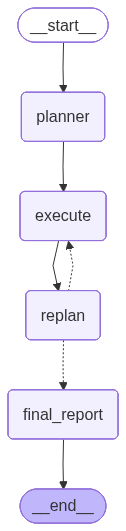

In [16]:
# 그래프 흐름: START → planner → execute → replan → (execute 또는 final_report) → END
# planner: 사용자 입력을 분석하여 단계별 실행 계획을 수립해요
# execute: 계획의 첫 번째 단계를 실행 에이전트로 수행해요
# replan: 실행 결과를 평가하고, 남은 계획이 있으면 execute로, 완료되면 final_report로 라우팅해요
# final_report: 완료된 모든 단계를 종합하여 최종 마크다운 보고서를 생성해요
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 8. 그래프 실행

이제 Plan-and-Execute 에이전트를 실행해봐요!

실행 시 중요한 설정:
- `recursion_limit`: 무한 루프 방지를 위한 최대 노드 실행 횟수예요. 계획 단계 수 × 3 정도로 설정해요.
- `thread_id`: 세션 ID예요. 같은 thread_id로 다시 실행하면 이전 상태에서 이어서 실행돼요.

> 💡 **실무 팁**: 복잡한 질문일수록 계획 단계가 많아지고 `recursion_limit`을 초과할 수 있어요. `recursion_limit`을 너무 낮게 설정하면 중간에 강제 종료되니, 충분히 여유 있게 설정하세요.

In [17]:
# ---------------------------------------------------
# 그래프 실행
# ---------------------------------------------------
import uuid
from langchain_core.runnables import RunnableConfig

# 실행 설정
# - recursion_limit: 최대 노드 실행 횟수 (무한 루프 방지)
# - thread_id: 세션 식별자 (uuid로 고유하게 생성해요)
config = RunnableConfig(
    recursion_limit=50,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 사용자 질문 설정
inputs = {
    "input": "AI 에이전트와 전통적인 워크플로우의 차이점을 설명하고, 각각의 장단점을 비교해줘"
}

# Plan-and-Execute 에이전트 실행 시작...
print(f"질문: {inputs['input']}")
# ============================================================

Plan-and-Execute 에이전트 실행 시작...
질문: AI 에이전트와 전통적인 워크플로우의 차이점을 설명하고, 각각의 장단점을 비교해줘


In [18]:
# ---------------------------------------------------
# 스트리밍 실행으로 각 노드 진행 상황 확인
# ---------------------------------------------------
# stream_mode="updates": 각 노드가 업데이트한 상태 변화만 출력해요
for chunk in app.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- [{node_name}] 노드 실행 ---")

        if node_name == "planner":
            # 수립된 계획 출력
            plan = node_output.get("plan", [])
            print(f"수립된 계획 ({len(plan)}단계):")
            for i, step in enumerate(plan, 1):
                print(f"  {i}. {step}")

        elif node_name == "execute":
            # 실행된 단계와 결과 요약 출력
            past_steps = node_output.get("past_steps", [])
            if past_steps:
                task, result = past_steps[-1]
                print(f"실행 단계: {task}")
                print(f"결과 요약: {result[:200]}...")

        elif node_name == "replan":
            # 재계획 결과 출력
            if "plan" in node_output:
                print(f"남은 계획: {node_output['plan']}")
            elif "response" in node_output:
                # 최종 응답 생성 완료 → final_report로 이동
                pass

        elif node_name == "final_report":
            # 최종 보고서 생성 완료
            pass

# ============================================================
# 실행 완료


--- [planner] 노드 실행 ---
수립된 계획 (2단계):
  1. AI 에이전트와 전통적인 워크플로우의 정의를 설명한다.
  2. 각각의 장단점을 비교하여 정리한다.

--- [execute] 노드 실행 ---
실행 단계: AI 에이전트와 전통적인 워크플로우의 정의를 설명한다.
결과 요약: AI 에이전트와 전통적인 워크플로우의 정의는 다음과 같습니다.

### AI 에이전트
AI 에이전트는 인공지능 기술을 활용하여 특정 작업을 수행하거나 문제를 해결하는 소프트웨어 프로그램입니다. 이러한 에이전트는 데이터 분석, 패턴 인식, 자연어 처리 등의 기능을 통해 인간의 개입 없이도 자동으로 결정을 내리거나 작업을 수행할 수 있습니다. AI 에이전트는 ...

--- [replan] 노드 실행 ---
남은 계획: ['각각의 장단점을 비교하여 정리한다.']

--- [execute] 노드 실행 ---
실행 단계: 각각의 장단점을 비교하여 정리한다.
결과 요약: ### AI 에이전트와 전통적인 워크플로우의 장단점 비교

#### AI 에이전트의 장점
1. **자동화**: 반복적인 작업을 자동으로 수행하여 시간과 인력을 절약할 수 있습니다.
2. **효율성**: 대량의 데이터를 신속하게 처리하고 분석할 수 있어 의사결정 속도가 빨라집니다.
3. **지속적인 학습**: 머신러닝 알고리즘을 통해 지속적으로 개선되고 적응...

--- [replan] 노드 실행 ---
최종 응답 생성 완료 → final_report로 이동

--- [final_report] 노드 실행 ---
최종 보고서 생성 완료

실행 완료


In [19]:
# ---------------------------------------------------
# 최종 결과 출력
# ---------------------------------------------------
from IPython.display import Markdown, display

# 그래프 실행 후 저장된 상태를 불러와요
snapshot = app.get_state(config).values

# 최종 응답을 마크다운으로 렌더링해요
display(Markdown(snapshot["response"]))

# 최종 보고서: AI 에이전트와 전통적인 워크플로우의 비교

**작성일:** 2026-04-01

## 1. 서론

본 보고서는 AI 에이전트와 전통적인 워크플로우의 차이점을 설명하고, 각각의 장단점을 비교하여 분석한 내용을 담고 있습니다. AI 기술의 발전과 함께 많은 기업들이 업무 프로세스를 자동화하고 효율성을 높이기 위해 AI 에이전트를 도입하고 있습니다. 이에 따라 전통적인 워크플로우와의 비교가 필요하게 되었습니다.

## 2. 정의

### 2.1 AI 에이전트
AI 에이전트는 인공지능 기술을 활용하여 특정 작업을 수행하거나 문제를 해결하는 소프트웨어 프로그램입니다. 데이터 분석, 패턴 인식, 자연어 처리 등의 기능을 통해 인간의 개입 없이도 자동으로 결정을 내리거나 작업을 수행할 수 있습니다. AI 에이전트는 머신러닝, 딥러닝, 알고리즘 등을 기반으로 하여 지속적으로 학습하고 개선될 수 있는 능력을 가지고 있습니다.

### 2.2 전통적인 워크플로우
전통적인 워크플로우는 인간의 개입과 수동적인 작업을 중심으로 구성된 프로세스입니다. 일반적으로 명확한 단계와 절차를 따르며, 각 단계는 특정 작업을 수행하는 사람이나 팀에 의해 관리됩니다. 전통적인 워크플로우는 문서화된 프로세스, 수동 입력, 그리고 인간의 판단에 의존하는 경향이 있습니다. 이러한 시스템은 종종 반복적이고 시간이 많이 소요되며, 오류가 발생할 가능성이 있습니다.

## 3. 장단점 비교

### 3.1 AI 에이전트의 장점
1. **자동화**: 반복적인 작업을 자동으로 수행하여 시간과 인력을 절약할 수 있습니다.
2. **효율성**: 대량의 데이터를 신속하게 처리하고 분석할 수 있어 의사결정 속도가 빨라집니다.
3. **지속적인 학습**: 머신러닝 알고리즘을 통해 지속적으로 개선되고 적응할 수 있습니다.
4. **오류 감소**: 인간의 개입이 적어 오류 발생 가능성이 줄어듭니다.
5. **24/7 운영**: 휴식 없이 지속적으로 작업을 수행할 수 있습니다.

### 3.2 AI 에이전트의 단점
1. **초기 비용**: 개발 및 구현에 높은 초기 비용이 발생할 수 있습니다.
2. **복잡성**: 시스템이 복잡하여 유지보수와 관리가 어려울 수 있습니다.
3. **데이터 의존성**: 정확한 결과를 위해서는 양질의 데이터가 필요합니다.
4. **윤리적 문제**: AI의 결정 과정이 불투명할 수 있어 윤리적 논란이 발생할 수 있습니다.
5. **인간의 역할 감소**: 일자리 감소와 같은 사회적 문제가 발생할 수 있습니다.

### 3.3 전통적인 워크플로우의 장점
1. **명확한 절차**: 각 단계가 명확하게 정의되어 있어 이해하기 쉽고 관리하기 용이합니다.
2. **인간의 판단**: 복잡한 상황에서 인간의 직관과 경험을 활용할 수 있습니다.
3. **유연성**: 변화하는 상황에 맞춰 절차를 쉽게 수정할 수 있습니다.
4. **낮은 초기 비용**: 기존의 시스템을 활용할 수 있어 초기 투자 비용이 적습니다.
5. **직원 참여**: 직원들이 직접 참여하여 책임감을 느낄 수 있습니다.

### 3.4 전통적인 워크플로우의 단점
1. **시간 소모**: 수동 작업이 많아 시간이 많이 소요됩니다.
2. **오류 가능성**: 인간의 실수로 인해 오류가 발생할 가능성이 높습니다.
3. **비효율성**: 반복적인 작업이 많아 비효율적일 수 있습니다.
4. **제한된 데이터 처리**: 대량의 데이터를 신속하게 처리하기 어렵습니다.
5. **의사결정 지연**: 인간의 개입이 필요하여 의사결정 속도가 느릴 수 있습니다.

## 4. 결론

AI 에이전트와 전통적인 워크플로우는 각각의 장단점이 있으며, 상황에 따라 적절한 선택이 필요합니다. AI 에이전트는 자동화와 효율성을 제공하지만 초기 비용과 복잡성 등의 단점이 존재합니다. 반면, 전통적인 워크플로우는 명확한 절차와 인간의 판단을 활용할 수 있지만, 시간 소모와 오류 가능성 등의 문제를 안고 있습니다. 따라서 기업은 자신의 필요와 환경에 맞춰 적절한 시스템을 선택하고 조화롭게 운영하는 것이 중요합니다.

## 9. 실습: 다양한 질문으로 테스트

아래 TODO 블록에서 직접 질문을 바꿔보고 Plan-and-Execute 에이전트의 동작을 실험해봐요.

> 🎯 **강의 포인트**: 질문의 복잡도에 따라 계획 단계 수가 어떻게 달라지는지 관찰해봐요. 간단한 사실 질문은 1~2단계, 비교 분석이나 리포트 작성은 3~5단계가 생성되는 경향이 있어요.

In [23]:
# ============================================================
# TODO: 아래 질문을 변경하고 Plan-and-Execute 동작을 실험해봐요
# 힌트:
#   - 간단한 사실 질문: "파이썬 최신 버전은 무엇인가요?"
#   - 비교 분석: "LangChain과 LlamaIndex의 차이점을 비교해줘"
#   - 리포트 작성: "생성형 AI 시장 현황과 주요 플레이어를 분석한 보고서 작성해줘"
# 예상 결과: 질문 복잡도에 따라 생성되는 계획 단계 수가 달라져요
# ============================================================

# 새로운 thread_id로 독립적인 세션을 시작해요
new_config = RunnableConfig(
    recursion_limit=50,
    configurable={"thread_id": str(uuid.uuid4())}
)

# TODO: 아래 질문을 자유롭게 변경해봐요
new_inputs = {
    "input": "LangGraph, LangChain 의 차이점과 각각의 장단점을 정리해서 보고서 및 인스타그램 게시용 글로 만들어."
}

print(f"질문: {new_inputs['input']}")
# 실행 중...

# 이번에는 최종 결과만 바로 가져와요
final_state = app.invoke(new_inputs, new_config)

print("\n계획 단계 수:", len(final_state.get("past_steps", [])))
# 완료된 단계:
for i, (task, _) in enumerate(final_state.get("past_steps", []), 1):
    print(f"  {i}. {task}")

질문: LangGraph, LangChain 의 차이점과 각각의 장단점을 정리해서 보고서 및 인스타그램 게시용 글로 만들어.
실행 중...

계획 단계 수: 2

완료된 단계:
  1. LangGraph와 LangChain의 정의를 정리한다.
  2. 각각의 주요 기능과 특징을 비교한다.


In [24]:
# ---------------------------------------------------
# 최종 보고서 출력
# ---------------------------------------------------
display(Markdown(final_state["response"]))

# LangGraph와 LangChain 비교 보고서

## 1. 서론
본 보고서는 LangGraph와 LangChain의 차이점과 각각의 장단점을 정리하여, 두 프레임워크의 특성을 이해하고 적절한 사용 사례를 제시하는 것을 목적으로 합니다.

## 2. LangGraph와 LangChain의 정의

### LangGraph
LangGraph는 자연어 처리(NLP)와 관련된 다양한 작업을 수행하기 위해 설계된 그래프 기반의 프레임워크입니다. 이 프레임워크는 언어 모델을 활용하여 데이터 간의 관계를 시각적으로 표현하고, 이를 통해 복잡한 언어 처리 작업을 보다 효율적으로 수행할 수 있도록 돕습니다. LangGraph는 특히 데이터의 흐름과 상호작용을 시각화하는 데 강점을 가지고 있습니다.

### LangChain
LangChain은 언어 모델을 활용하여 다양한 애플리케이션을 구축할 수 있도록 지원하는 프레임워크입니다. 이 프레임워크는 언어 모델과 외부 데이터 소스, API, 데이터베이스 등을 연결하여 복잡한 작업을 자동화하고, 사용자와의 상호작용을 개선하는 데 중점을 두고 있습니다. LangChain은 특히 대화형 애플리케이션, 챗봇, 정보 검색 시스템 등에서 유용하게 사용됩니다.

## 3. 주요 기능과 특징 비교

### LangGraph
- **상태 관리 (State Management)**: 자동 상태 관리 기능을 제공하여 여러 상호작용에 걸쳐 정보를 추적하고 유지합니다.
- **조정 (Coordination)**: 여러 에이전트가 올바른 순서로 실행되고 필요한 정보가 원활하게 교환되도록 보장합니다.
- **개발 간소화 (Simplified Development)**: 상태 관리 및 에이전트 조정의 복잡성을 추상화하여 개발자가 애플리케이션의 고수준 논리에 집중할 수 있게 합니다.
- **유연성 (Flexibility)**: 개발자는 자신의 에이전트 로직과 통신 프로토콜을 정의할 수 있어 맞춤형 애플리케이션을 쉽게 만들 수 있습니다.
- **확장성 (Scalability)**: 대규모 멀티 에이전트 애플리케이션의 실행을 지원합니다.
- **내결함성 (Fault Tolerance)**: 오류를 우아하게 처리하는 메커니즘을 포함하여, 개별 에이전트에 문제가 발생해도 애플리케이션이 계속 작동할 수 있습니다.

### LangChain
- **체이닝 (Chaining)**: 다양한 구성 요소를 연결하여 LLM 기반 애플리케이션을 위한 일관된 워크플로를 만듭니다.
- **데이터 연결 및 검색 (Data Connection and Retrieval)**: 외부 데이터 소스와의 연결을 통해 실시간 데이터를 활용할 수 있습니다.
- **메모리 (Memory)**: 대화의 문맥을 유지할 수 있도록 메모리 기능을 제공하여 이전의 내용을 기억하고 새로운 답변을 생성할 수 있습니다.
- **에이전트 (Agents)**: LLM이 자동으로 여러 도구를 선택하고 사용하는 방식으로, API 호출이나 데이터베이스 검색 등의 작업을 수행할 수 있습니다.
- **모듈성 (Modularity)**: 체인, 에이전트, 메모리 등을 필요에 따라 조합해 다양한 기능을 구현할 수 있습니다.
- **자동화 (Automation)**: 에이전트가 도구를 선택해 자동으로 작업을 수행하여 복잡한 작업을 스스로 해결할 수 있습니다.

## 4. 요약
- **LangGraph**는 상태 관리와 에이전트 조정에 중점을 두어 복잡한 언어 처리 작업을 간소화하고, 유연성과 확장성을 제공합니다.
- **LangChain**은 체이닝을 통해 다양한 구성 요소를 연결하여 LLM 기반 애플리케이션을 쉽게 구축할 수 있도록 하며, 데이터 연결과 메모리 기능을 통해 사용자 경험을 향상시킵니다.

이 두 프레임워크는 각각의 강점을 가지고 있으며, 특정 사용 사례에 따라 선택할 수 있습니다.

## 5. 결론
LangGraph와 LangChain은 자연어 처리 및 언어 모델 기반 애플리케이션 개발에 있어 중요한 도구입니다. 각 프레임워크의 특성을 이해하고 적절히 활용함으로써, 보다 효율적이고 효과적인 애플리케이션을 개발할 수 있을 것입니다.

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Plan-and-Execute 패턴**: 복잡한 작업을 계획 수립 → 단계별 실행 → 동적 재계획으로 처리하는 에이전트 아키텍처예요
- **`PlanExecute` 상태**: `plan`(덮어쓰기), `past_steps`(`operator.add`로 누적), `response`(종료 신호)로 구성된 상태 설계 패턴이에요
- **구조화된 출력**: `with_structured_output(Plan)`, `with_structured_output(Act)`로 LLM이 Pydantic 모델 형식으로 응답하도록 강제해요
- **비용 최적화**: 계획/재계획 단계에는 강력한 모델, 반복 실행 단계에는 경량 모델을 사용하여 비용을 절감해요
- **동적 재계획**: Replanner가 실행 결과를 평가하여 Plan(계속) 또는 Response(종료)를 선택해요
- **최종 보고서 노드**: 완료된 모든 단계를 종합하여 전문적인 마크다운 보고서를 생성해요

## 다음 노트북 예고

다음 `02-SQL-Agent.ipynb`에서는 **자연어를 SQL로 변환하는 에이전트**를 배워요. `SQLDatabaseToolkit`으로 테이블 목록 조회 → 스키마 확인 → 쿼리 생성 → 검증 → 실행 → 답변까지 7단계를 자동화하고, **오류 발생 시 LLM이 스스로 쿼리를 수정**하는 자가 수정 루프를 구현해요. 이번 Plan-and-Execute의 "실행 단계"를 SQL로 특화한 실전 예제예요.

<!-- AUTOPILOT_CREATE_AGENT_DEEP_AGENT_APPENDIX -->
## 보강: `create_deep_agent`로 Plan-and-Execute를 더 높은 수준의 에이전트 하네스로 확장하기

### 참고 공식 문서
- [Deep Agents overview](https://docs.langchain.com/oss/python/deepagents/overview)
- [Deep Agents customization](https://docs.langchain.com/oss/python/deepagents/customization)

앞에서는 Planner / Executor / Replanner를 `StateGraph`로 직접 연결해서 Plan-and-Execute의 내부 동작을 학습했어요. 이 방식은 **노드·엣지·상태를 눈으로 확인하는 교육용 구현**으로 매우 좋습니다. 다만 실무에서 긴 작업을 오래 실행해야 한다면, 공식 Deep Agents 문서가 설명하는 `create_deep_agent` 하네스를 선택할 수 있어요.

공식 문서 기준으로 Deep Agents가 특히 유리한 지점은 다음과 같아요.

- **계획/분해 내장**: `write_todos` 도구로 장기 작업을 작은 단계로 나누고 진행 상황을 관리해요.
- **컨텍스트 외부화**: `read_file`, `write_file`, `edit_file` 같은 파일 도구로 긴 산출물과 중간 결과를 대화창 밖에 저장해요.
- **서브에이전트 위임**: `subagents=[...]`로 리서처·리뷰어·작성자처럼 전문 역할을 분리해 메인 에이전트의 컨텍스트를 깨끗하게 유지해요.
- **LangGraph 런타임 활용**: durable execution, streaming, HITL 같은 LangGraph의 장점은 유지하면서 하네스 수준의 기본 기능을 얻어요.

따라서 이 노트북의 직접 구현은 “원리를 이해하기 위한 분해도”, 아래 `create_deep_agent` 예시는 “실무에서 바로 시작하기 좋은 고수준 구현”으로 보면 됩니다.

> 실행 전제: 아래 셀은 선택 실행 예시입니다. API 키와 `deepagents` 설치 상태를 확인한 뒤 `RUN_DEEP_AGENT_PLAN_APPENDIX = True`로 바꾸세요.


In [ ]:
# ============================================================
# 선택 실행: create_deep_agent 기반 Plan-and-Execute 하네스
# ============================================================
# 이 셀은 기본값으로 실행되지 않아요. 실습하려면 True로 변경하세요.
RUN_DEEP_AGENT_PLAN_APPENDIX = False

if RUN_DEEP_AGENT_PLAN_APPENDIX:
    from deepagents import create_deep_agent
    from langchain.tools import tool

    # --------------------------------------------------------
    # 1) 기존 노트북의 도구를 Deep Agent 도구로 재사용
    # --------------------------------------------------------
    # @tool 데코레이터를 사용하면 함수의 이름/설명/타입 힌트가
    # 모델이 호출할 수 있는 도구 스키마로 변환돼요.
    @tool(parse_docstring=True)
    def search_summary(query: str) -> str:
        """Search and summarize a topic for one execution step.

        Args:
            query: The focused research question or execution step.
        """
        # 실제 서비스에서는 Tavily, 내부 문서 검색, SQL, API 호출 등을 연결하세요.
        # 여기서는 교육용 스텁으로 남겨 두어 노트북 재실행이 외부 API에 의존하지 않게 해요.
        return f"[검색 요약 스텁] {query}에 대한 핵심 근거를 요약합니다."

    # --------------------------------------------------------
    # 2) 전문 서브에이전트 정의
    # --------------------------------------------------------
    # Deep Agents 문서의 subagents 패턴처럼, 메인 에이전트는 큰 목표를 잡고
    # 세부 조사/검증은 context-isolated 서브에이전트에게 위임할 수 있어요.
    research_subagent = {
        "name": "researcher",
        "description": "복잡한 실행 단계에 필요한 근거를 조사하고 간결한 요약을 반환합니다.",
        "system_prompt": (
            "너는 리서치 전담 서브에이전트다. "
            "하나의 하위 과제만 깊게 조사하고, 최종 답변에는 핵심 근거와 남은 불확실성을 포함한다."
        ),
        "tools": [search_summary],
    }

    # --------------------------------------------------------
    # 3) Plan-and-Execute 성격의 Deep Agent 생성
    # --------------------------------------------------------
    deep_plan_agent = create_deep_agent(
        model="openai:gpt-4o-mini",
        tools=[search_summary],
        subagents=[research_subagent],
        system_prompt="""
너는 Plan-and-Execute 스타일의 작업 관리자다.
항상 다음 순서로 작업한다.
1. write_todos로 전체 계획을 먼저 작성한다.
2. 각 TODO를 하나씩 실행한다.
3. 조사 범위가 커지면 researcher 서브에이전트에게 위임한다.
4. 마지막에는 완료한 단계, 사용한 근거, 남은 리스크를 보고한다.
""",
    )

    # --------------------------------------------------------
    # 4) 실행 예시
    # --------------------------------------------------------
    result = deep_plan_agent.invoke({
        "messages": [{
            "role": "user",
            "content": "생성형 AI 교육 과정 개선안을 조사하고 실행 계획으로 정리해줘.",
        }]
    })

    # 최종 메시지만 간단히 확인해요.
    print(result["messages"][-1].content)
